# Simple Grid World: On-Policy State Distribution

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [32]:
import numpy as np
np.set_printoptions(precision=2)

In [33]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Load the 3x4 Grid World 

In [34]:
gym_env = gym.make('ClassicGridworld-v1')
env = gym_env.unwrapped

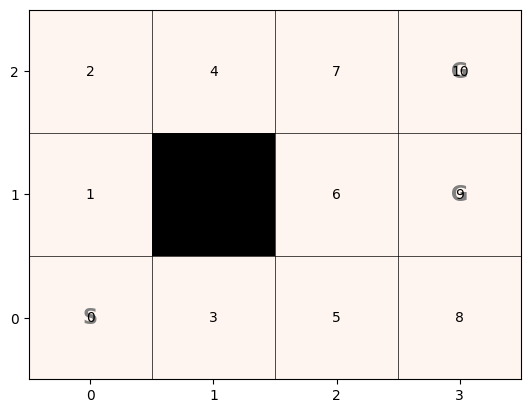

In [35]:
env.image()

## Definition

In reinforcement learning, the on-policy distribution (also called the state distribution under a policy) is the probability distribution over states 
(i.e., the proportion of time spent in each state) that results from following a specific policy in a given environment.
When the agent follows the policy, then it will encounter states with that distribution. That means, if we sample episodes using the policy, we will also sample states with this distribution. We can argue that states that the agent occupies more often are more important.

**Time horizon issues:**

A typical assumption is that we have a discounted infinite horizon problem which leads to a stationary discounted state visitation distribution.

A finite-horizon problems, in general, do not have stationary distributions. However, if
* the horizon is large,
* the policy is time-independent, and
* the MDP is ergodic,

then for intermediate time steps (far from start and end), the state distribution may approximately resemble a stationary distribution.

We satisfy the three requirements in the following way:
* We restart a new episode when the last one ends. This is the typical trick to creating a very large or even infinite horizon problem.
* We have a fixed policy.
* The MDP is ergodic. Ergodic means:
   - Irreducible: Every state is eventually reachable from every other state.
   - Aperiodic: The system does not get trapped in deterministic cycles. 

So we will get a near stationary distribution for the maze





## Estimate the On-Policy Distribution

First, we need a policy. We just create the optimal policy using value iteration. 

..............
Converged after 14 sweeps.


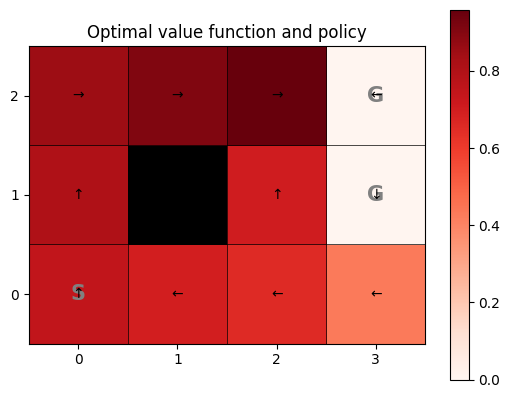

In [36]:
from gym_classics.algorithms.dynamic_programming import value_iteration
from gym_classics.algorithms.policy import greedy_policy

V_star = value_iteration(env, discount=1, verbose=True)
pol_star = greedy_policy(env, V_star)
env.image(V_star, policy=pol_star, title="Optimal value function and policy")


If we have the transition model, then the stationary distribution for an infinite horizon problem can be calculated directly. 
Here we use sampling episodes to approximate the distribution.

In [ ]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

def on_policy_state_distribution(env, pol, discount = 1, epsilon = 0, n = 1):
    """Estimate the (discounted) state distribution of a policy by sampling episodes."""
    state_cnts = np.zeros(env.observation_space.n)
    
    for _ in range(n):
        episode = np.array(sample_episode(env, policy=pol, epsilon = epsilon))
        states = np.append(episode[:,0], episode[-1,3])
        
        # all 1's for discount = 1, otherwise discounted counts
        discounts = np.array([discount**i for i in range(len(states))])
        for s, d in zip(states, discounts):
            state_cnts[int(s)] += d
    
    state_prob = state_cnts / sum(state_cnts)
    return state_prob

mu= [0.16 0.18 0.16 0.02 0.17 0.   0.02 0.16 0.   0.   0.13]
sum(mu)= 1.0


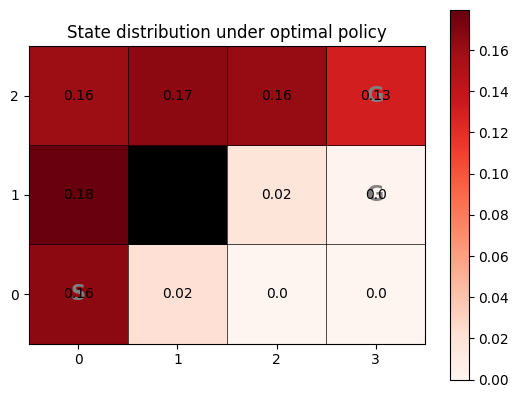

In [38]:
mu = on_policy_state_distribution(env, pol_star, discount = 1, n = 1000)
print("mu=", mu)
print("sum(mu)=", np.sum(mu))

env.image(mu, labels = True, title = "State distribution under optimal policy")


This distribution is for example used for the following: 

* Weight the mean squared value error $\overline{VE}$ for approximating value functions.
* In the objective for the Policy Gradient Theorem.
* In general in on-policy methods. 


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)